# 05: LoRA Hyperparameter Search

This notebook implements a systematic hyperparameter search for LoRA fine-tuning on the Qwen2.5-Instruct model:

1. Search over learning rates: 1e-5, 5e-5, 1e-4
2. Search over LoRA ranks: 2, 4, 8
3. Track FLOPS usage for all experiments

We'll also examine the effect of context length in a follow-up experiment.

In [50]:
import sys
import os
import itertools
import json
import pickle
import torch
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, TensorDataset
from accelerate import Accelerator
from IPython.display import display, Markdown
from datetime import datetime

# Add parent directory to the path
sys.path.append(os.path.abspath('..'))

# Import project modules
from src.utils.lora import (LoRALinear, apply_lora_to_model, process_sequences, 
                      train_lora, evaluate_model, create_train_val_loaders)
from src.preprocessor import load_and_preprocess
from src.utils.flops_calculator import calculate_lora_flops
from qwen import load_qwen

# Configure plotting
plt.style.use('mystyle.mplstyle')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Data Preparation

In [51]:
# Load the preprocessed data
with open('../data/formatted_train.pkl', 'rb') as f:
    train_texts = pickle.load(f)

# Separate training and validation data
train_texts, val_texts = train_texts[:700], train_texts[700:]


print(f"Number of training sequences: {len(train_texts)}")
print(f"Number of validation sequences: {len(val_texts)}")
print(f"\nSample sequence:\n{train_texts[0][:100]}...")

Number of training sequences: 700
Number of validation sequences: 100

Sample sequence:
1.71,1.93;1.54,1.71;1.46,1.49;1.45,1.29;1.52,1.12;1.64,0.99;1.84,0.89;2.09,0.82;2.41,0.78;2.79,0.78;...


## 2. Hyperparameter Search Configuration

Let's set up our hyperparameter grid search:

In [52]:
model, tokenizer = load_qwen()
# Define hyperparameter grid
learning_rates = [1e-5, 5e-5, 1e-4]
lora_ranks = [2, 4, 8]

# Fixed parameters for this search
max_ctx_length = 256  # Fixed context length for the main search
batch_size = 2
max_steps = 10  # As specified in the assignment
eval_steps = 5
logging_steps = 10

# Set up results directory
base_output_dir = "../results/lora/hyperparam_search"
os.makedirs(base_output_dir, exist_ok=True)

# Initialize results tracking
results = []
total_flops_used = 0

# Create dataloaders for training and validation
train_loader, val_loader = create_train_val_loaders(
    train_texts, val_texts, 
    tokenizer=tokenizer,
    max_ctx_length=max_ctx_length, 
    batch_size=batch_size
)

2025-03-26 23:30:41,212 - src.utils.lora - INFO - Creating data loaders with max_ctx_length=256, batch_size=2
2025-03-26 23:30:41,226 - src.utils.lora - INFO - Processing 700 training sequences
2025-03-26 23:30:41,227 - src.utils.lora - INFO - Processing 700 sequences with max_length=256, stride=128
Processing sequences: 100%|██████████| 700/700 [00:00<00:00, 760.08it/s]
2025-03-26 23:30:42,165 - src.utils.lora - INFO - Created 5616 total chunks from 700 sequences
2025-03-26 23:30:42,173 - src.utils.lora - INFO - Processing 100 validation sequences
2025-03-26 23:30:42,174 - src.utils.lora - INFO - Processing 100 sequences with max_length=256, stride=256
Processing sequences: 100%|██████████| 100/100 [00:00<00:00, 831.88it/s]
2025-03-26 23:30:42,296 - src.utils.lora - INFO - Created 402 total chunks from 100 sequences
2025-03-26 23:30:42,298 - src.utils.lora - INFO - Created train loader with 5616 samples and val loader with 402 samples


In [53]:
# Initialize W&B project
wandb.init(project="lora-hyperparameter-search", name="initial-setup")

# Log your fixed parameters as config
wandb.config.update({
    "max_ctx_length": max_ctx_length,
    "batch_size": batch_size,
    "max_steps": max_steps,
    "eval_steps": eval_steps,
    "logging_steps": logging_steps
})

# echo 'export WANDB_API_KEY=ec24d2c84a347e90b637b1023ec7804363dcc81f' >> ~/.bashrc
# source ~/.bashrc

## 3. FLOPS Budget Planning

In [54]:
def estimate_experiment_flops(batch_size, seq_length, r, steps):
    # Calculate training FLOPS
    training_flops = calculate_lora_flops(
        batch_size=batch_size,
        seq_length=seq_length,
        r=r,
        steps=steps,
        is_training=True
    )['combined_total']
    
    # Calculate inference FLOPS (assuming 2 eval steps for every 50 training steps)
    eval_steps = max(1, steps // 25)
    inference_flops = calculate_lora_flops(
        batch_size=batch_size,
        seq_length=seq_length,
        r=r,
        steps=eval_steps,
        is_training=False
    )['combined_total']
    
    return training_flops + inference_flops

In [55]:
# Calculate estimated FLOPS for all main experiments
total_estimated_flops = 0
# Single experiment
initial_flops = estimate_experiment_flops(batch_size=8, seq_length=512, r=4, steps=1000)
total_estimated_flops += initial_flops
print(f"Initial experiment - Estimated FLOPS: {initial_flops:,.0f}")
print(f"Percentage of 10^17 FLOPS budget: {total_estimated_flops/1e17:.2%}")

2025-03-26 23:30:42,575 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 4, over 1000 steps in training mode
2025-03-26 23:30:42,578 - src.utils.flops_calculator - INFO - Training FLOPs: forward=4,512,331,116,544, backward=9,024,662,233,088, total=13,536,993,349,632
2025-03-26 23:30:42,579 - src.utils.flops_calculator - INFO - LoRA overhead: 0.06% FLOPs per step compared to standard training
2025-03-26 23:30:42,580 - src.utils.flops_calculator - INFO - Total LoRA training FLOPs: 13,545,446,707,200,000 for 1000 steps
2025-03-26 23:30:42,580 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 4, over 40 steps in inference mode
2025-03-26 23:30:42,581 - src.utils.flops_calculator - INFO - Inference FLOPs: total=4,512,331,116,544
2025-03-26 23:30:42,582 - src.utils.flops_calculator - INFO - LoRA overhead: 0.06% FLOPs per step compared to standard inference
2025-03-26 23:30:42,583 - src.utils.flops_calculator - INFO - To

Initial experiment - Estimated FLOPS: 13,726,052,663,296,000
Percentage of 10^17 FLOPS budget: 13.73%


In [56]:
# All main experiments
for lr, r in itertools.product(learning_rates, lora_ranks):
    exp_flops = estimate_experiment_flops(batch_size=8, seq_length=512, r=r, steps=250)
    total_estimated_flops += exp_flops
    print(f"LR: {lr}, Rank: {r} - Estimated FLOPS: {exp_flops:,.0f}")

# Add estimates for the context length experiments
context_lengths = [128, 768] # 512 is already included in the main search
best_rank = 8
for ctx_len in context_lengths:
    ctx_flops = estimate_experiment_flops(8, ctx_len, best_rank, 200)
    total_estimated_flops += ctx_flops
    print(f"Context length: {ctx_len} - Estimated FLOPS: {ctx_flops:,.0f}")

print(f"Percentage of 10^17 FLOPS budget: {total_estimated_flops/1e17:.2%}")

2025-03-26 23:30:42,605 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 2, over 250 steps in training mode
2025-03-26 23:30:42,608 - src.utils.flops_calculator - INFO - Training FLOPs: forward=4,512,331,116,544, backward=9,024,662,233,088, total=13,536,993,349,632
2025-03-26 23:30:42,609 - src.utils.flops_calculator - INFO - LoRA overhead: 0.03% FLOPs per step compared to standard training
2025-03-26 23:30:42,610 - src.utils.flops_calculator - INFO - Total LoRA training FLOPs: 3,385,305,007,104,000 for 250 steps
2025-03-26 23:30:42,611 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 2, over 10 steps in inference mode
2025-03-26 23:30:42,612 - src.utils.flops_calculator - INFO - Inference FLOPs: total=4,512,331,116,544
2025-03-26 23:30:42,613 - src.utils.flops_calculator - INFO - LoRA overhead: 0.03% FLOPs per step compared to standard inference
2025-03-26 23:30:42,614 - src.utils.flops_calculator - INFO - Total

LR: 1e-05, Rank: 2 - Estimated FLOPS: 3,430,442,407,198,720
LR: 1e-05, Rank: 4 - Estimated FLOPS: 3,431,513,165,824,000
LR: 1e-05, Rank: 8 - Estimated FLOPS: 3,433,654,683,074,560
LR: 5e-05, Rank: 2 - Estimated FLOPS: 3,430,442,407,198,720
LR: 5e-05, Rank: 4 - Estimated FLOPS: 3,431,513,165,824,000
LR: 5e-05, Rank: 8 - Estimated FLOPS: 3,433,654,683,074,560


2025-03-26 23:30:42,794 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 4, over 250 steps in training mode
2025-03-26 23:30:42,795 - src.utils.flops_calculator - INFO - Training FLOPs: forward=4,512,331,116,544, backward=9,024,662,233,088, total=13,536,993,349,632
2025-03-26 23:30:42,796 - src.utils.flops_calculator - INFO - LoRA overhead: 0.06% FLOPs per step compared to standard training
2025-03-26 23:30:42,797 - src.utils.flops_calculator - INFO - Total LoRA training FLOPs: 3,386,361,676,800,000 for 250 steps
2025-03-26 23:30:42,798 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 4, over 10 steps in inference mode
2025-03-26 23:30:42,799 - src.utils.flops_calculator - INFO - Inference FLOPs: total=4,512,331,116,544


LR: 0.0001, Rank: 2 - Estimated FLOPS: 3,430,442,407,198,720


2025-03-26 23:30:42,837 - src.utils.flops_calculator - INFO - LoRA overhead: 0.06% FLOPs per step compared to standard inference
2025-03-26 23:30:42,847 - src.utils.flops_calculator - INFO - Total LoRA inference FLOPs: 45,151,489,024,000 for 10 steps
2025-03-26 23:30:42,848 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 8, over 250 steps in training mode
2025-03-26 23:30:42,849 - src.utils.flops_calculator - INFO - Training FLOPs: forward=4,512,331,116,544, backward=9,024,662,233,088, total=13,536,993,349,632
2025-03-26 23:30:42,849 - src.utils.flops_calculator - INFO - LoRA overhead: 0.12% FLOPs per step compared to standard training
2025-03-26 23:30:42,850 - src.utils.flops_calculator - INFO - Total LoRA training FLOPs: 3,388,475,016,192,000 for 250 steps
2025-03-26 23:30:42,850 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 8, over 10 steps in inference mode
2025-03-26 23:30:42,851 - src.utils.flops_calcul

LR: 0.0001, Rank: 4 - Estimated FLOPS: 3,431,513,165,824,000
LR: 0.0001, Rank: 8 - Estimated FLOPS: 3,433,654,683,074,560
Context length: 128 - Estimated FLOPS: 665,202,681,479,168
Context length: 768 - Estimated FLOPS: 4,206,498,640,232,448
Percentage of 10^17 FLOPS budget: 49.48%


In [57]:
# Calculate final experiment FLOPS
final_flops = estimate_experiment_flops(8, 768, best_rank, 2000)
total_estimated_flops += final_flops
print(f"\nFinal experiment (30k steps) - Estimated FLOPS: {final_flops:,.0f}")

print(f"\nTotal estimated FLOPS for all experiments: {total_estimated_flops:,.0f}")
print(f"Percentage of 10^17 FLOPS budget: {total_estimated_flops/1e17:.2%}")

2025-03-26 23:30:59,357 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 8, over 2000 steps in training mode
2025-03-26 23:30:59,358 - src.utils.flops_calculator - INFO - Training FLOPs: forward=6,910,129,932,288, backward=13,820,259,864,576, total=20,730,389,796,864
2025-03-26 23:30:59,359 - src.utils.flops_calculator - INFO - LoRA overhead: 0.12% FLOPs per step compared to standard training
2025-03-26 23:30:59,359 - src.utils.flops_calculator - INFO - Total LoRA training FLOPs: 41,511,499,739,136,000 for 2000 steps
2025-03-26 23:30:59,360 - src.utils.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 8, over 80 steps in inference mode
2025-03-26 23:30:59,360 - src.utils.flops_calculator - INFO - Inference FLOPs: total=6,910,129,932,288
2025-03-26 23:30:59,361 - src.utils.flops_calculator - INFO - LoRA overhead: 0.12% FLOPs per step compared to standard inference
2025-03-26 23:30:59,361 - src.utils.flops_calculator - INFO - T


Final experiment (30k steps) - Estimated FLOPS: 42,064,986,402,324,480

Total estimated FLOPS for all experiments: 91,549,571,155,623,936
Percentage of 10^17 FLOPS budget: 91.55%


## 4. Hyperparameter Search

a small hyperparameter search over learning rates and LoRA ranks

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



--------------------------------------------------------------------------------
Running experiment: lr_1e-05_rank_2
--------------------------------------------------------------------------------


2025-03-23 14:45:46,418 - src.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-23 14:45:46,419 - src.lora - INFO - Applying LoRA with rank 2 and alpha 2
2025-03-23 14:45:46,420 - src.lora - INFO - Original trainable parameters: 151,936
2025-03-23 14:45:46,430 - src.lora - INFO - Applied LoRA with rank 2 to 48 ['q_proj', 'v_proj'] modules
2025-03-23 14:45:46,431 - src.lora - INFO - Trainable parameters: 287,104 (original: 151,936, ratio: 1.889638)
Evaluating: 100%|██████████| 20/20 [00:15<00:00,  1.33it/s]
2025-03-23 14:46:12,343 - src.lora - INFO - Training with batch_size=2, seq_length=256
2025-03-23 14:46:12,348 - src.lora - INFO - Output directory: ../results/lora/hyperparam_search/lr_1e-05_rank_2
2025-03-23 14:46:12,350 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:46:12,351 - src.lora - INFO - Estimated FLOPs per step: 1,656,715,854,336
2025-03-23 14:46:12,352 - src

Initial validation loss: 1.2500


Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.35it/s]
2025-03-23 14:46:30,006 - src.lora - INFO - Step 5: Eval loss = 1.2494, perplexity = 3.4883
Training: 100%|██████████| 10/10 [00:24<00:00,  2.00s/it, loss=1.62]2025-03-23 14:46:36,633 - src.lora - INFO - Step 10: Train loss = 1.6231, FLOPS used = 1.66e+13
2025-03-23 14:46:36,634 - src.lora - INFO - Evaluating at step 10...
Evaluating: 100%|██████████| 20/20 [00:09<00:00,  2.19it/s]
2025-03-23 14:46:45,805 - src.lora - INFO - Step 10: Eval loss = 1.2488, perplexity = 3.4862
Training: 100%|██████████| 10/10 [00:33<00:00,  3.34s/it, loss=1.62]
2025-03-23 14:46:45,806 - src.lora - INFO - Training completed with 10 steps. Best eval loss: 1.2488
2025-03-23 14:46:45,811 - src.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 2, over 10 steps
2025-03-23 14:46:45,812 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:46:45,81

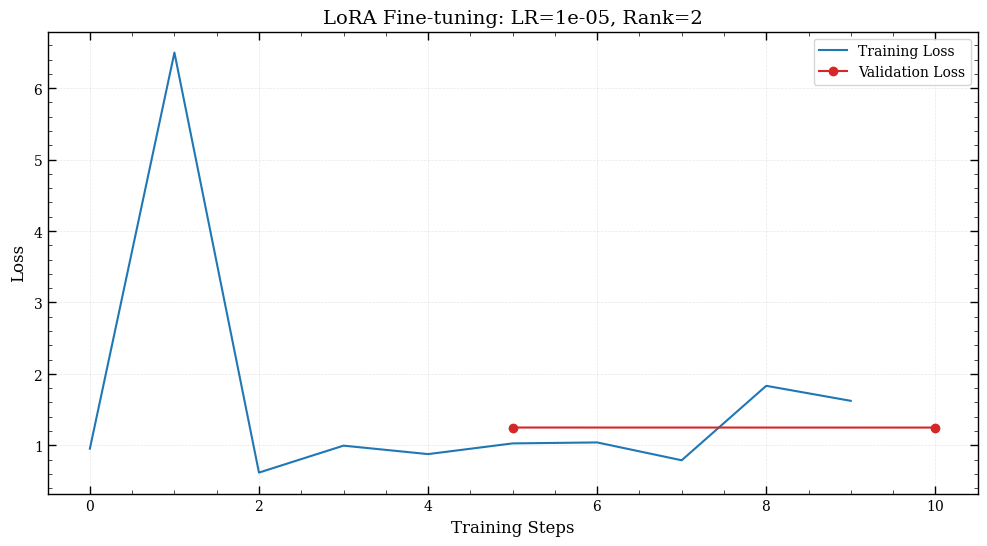

Experiment lr_1e-05_rank_2 completed. FLOPS used: 16,572,441,891,840
Total FLOPS used so far: 16,572,441,891,840 (0.02% of budget)


initial_perplexity,▁
initial_val_loss,▁
initial_perplexity,3.49036
initial_val_loss,1.25


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



--------------------------------------------------------------------------------
Running experiment: lr_1e-05_rank_4
--------------------------------------------------------------------------------


2025-03-23 14:46:54,675 - src.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-23 14:46:54,677 - src.lora - INFO - Applying LoRA with rank 4 and alpha 4
2025-03-23 14:46:54,679 - src.lora - INFO - Original trainable parameters: 151,936
2025-03-23 14:46:54,688 - src.lora - INFO - Applied LoRA with rank 4 to 48 ['q_proj', 'v_proj'] modules
2025-03-23 14:46:54,688 - src.lora - INFO - Trainable parameters: 422,272 (original: 151,936, ratio: 2.779275)
Evaluating: 100%|██████████| 20/20 [00:09<00:00,  2.20it/s]
2025-03-23 14:47:05,021 - src.lora - INFO - Training with batch_size=2, seq_length=256
2025-03-23 14:47:05,023 - src.lora - INFO - Output directory: ../results/lora/hyperparam_search/lr_1e-05_rank_4
2025-03-23 14:47:05,024 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:47:05,025 - src.lora - INFO - Estimated FLOPs per step: 1,656,715,854,336
2025-03-23 14:47:05,026 - src

Initial validation loss: 1.2500


Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.23it/s]
2025-03-23 14:47:20,551 - src.lora - INFO - Step 5: Eval loss = 1.2473, perplexity = 3.4810
Training: 100%|██████████| 10/10 [00:22<00:00,  1.97s/it, loss=1.02] 2025-03-23 14:47:27,112 - src.lora - INFO - Step 10: Train loss = 1.0171, FLOPS used = 1.66e+13
2025-03-23 14:47:27,113 - src.lora - INFO - Evaluating at step 10...
Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.36it/s]
2025-03-23 14:47:35,591 - src.lora - INFO - Step 10: Eval loss = 1.2458, perplexity = 3.4759
Training: 100%|██████████| 10/10 [00:30<00:00,  3.06s/it, loss=1.02]
2025-03-23 14:47:35,593 - src.lora - INFO - Training completed with 10 steps. Best eval loss: 1.2458
2025-03-23 14:47:35,600 - src.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 4, over 10 steps
2025-03-23 14:47:35,606 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:47:35,6

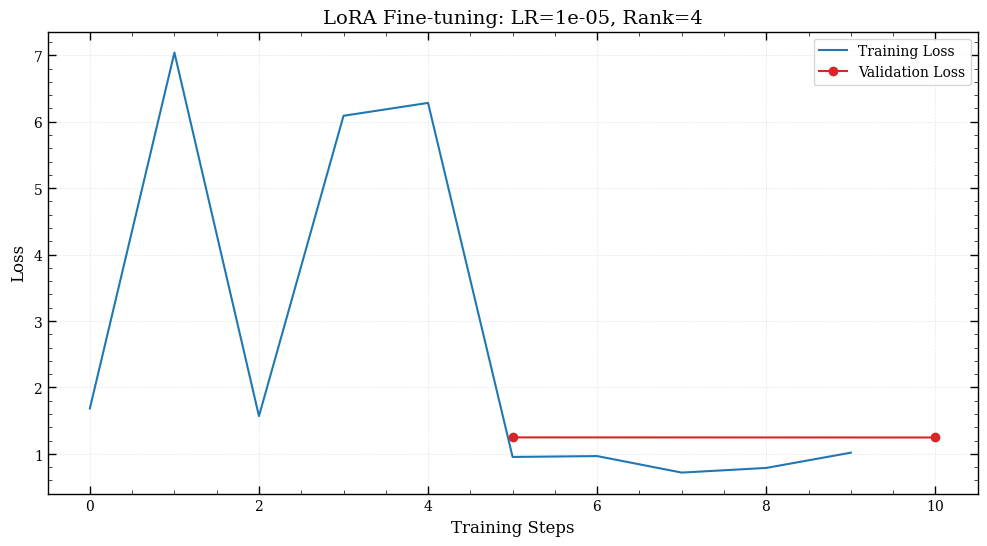

Experiment lr_1e-05_rank_4 completed. FLOPS used: 16,577,725,240,320
Total FLOPS used so far: 33,150,167,132,160 (0.03% of budget)


initial_perplexity,▁
initial_val_loss,▁
initial_perplexity,3.49036
initial_val_loss,1.25


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



--------------------------------------------------------------------------------
Running experiment: lr_1e-05_rank_8
--------------------------------------------------------------------------------


2025-03-23 14:47:42,677 - src.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-23 14:47:42,679 - src.lora - INFO - Applying LoRA with rank 8 and alpha 8
2025-03-23 14:47:42,680 - src.lora - INFO - Original trainable parameters: 151,936
2025-03-23 14:47:42,707 - src.lora - INFO - Applied LoRA with rank 8 to 48 ['q_proj', 'v_proj'] modules
2025-03-23 14:47:42,717 - src.lora - INFO - Trainable parameters: 692,608 (original: 151,936, ratio: 4.558551)
Evaluating: 100%|██████████| 20/20 [00:09<00:00,  2.03it/s]
2025-03-23 14:47:54,177 - src.lora - INFO - Training with batch_size=2, seq_length=256
2025-03-23 14:47:54,179 - src.lora - INFO - Output directory: ../results/lora/hyperparam_search/lr_1e-05_rank_8
2025-03-23 14:47:54,180 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:47:54,181 - src.lora - INFO - Estimated FLOPs per step: 1,656,715,854,336
2025-03-23 14:47:54,181 - src

Initial validation loss: 1.2500


Evaluating: 100%|██████████| 20/20 [00:09<00:00,  2.16it/s]
2025-03-23 14:48:10,234 - src.lora - INFO - Step 5: Eval loss = 1.2434, perplexity = 3.4675
Training: 100%|██████████| 10/10 [00:22<00:00,  2.00s/it, loss=1.73]2025-03-23 14:48:16,847 - src.lora - INFO - Step 10: Train loss = 1.7327, FLOPS used = 1.66e+13
2025-03-23 14:48:16,848 - src.lora - INFO - Evaluating at step 10...
Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.35it/s]
2025-03-23 14:48:25,348 - src.lora - INFO - Step 10: Eval loss = 1.2399, perplexity = 3.4553
Training: 100%|██████████| 10/10 [00:31<00:00,  3.12s/it, loss=1.73]
2025-03-23 14:48:25,349 - src.lora - INFO - Training completed with 10 steps. Best eval loss: 1.2399
2025-03-23 14:48:25,357 - src.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 8, over 10 steps
2025-03-23 14:48:25,357 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:48:25,35

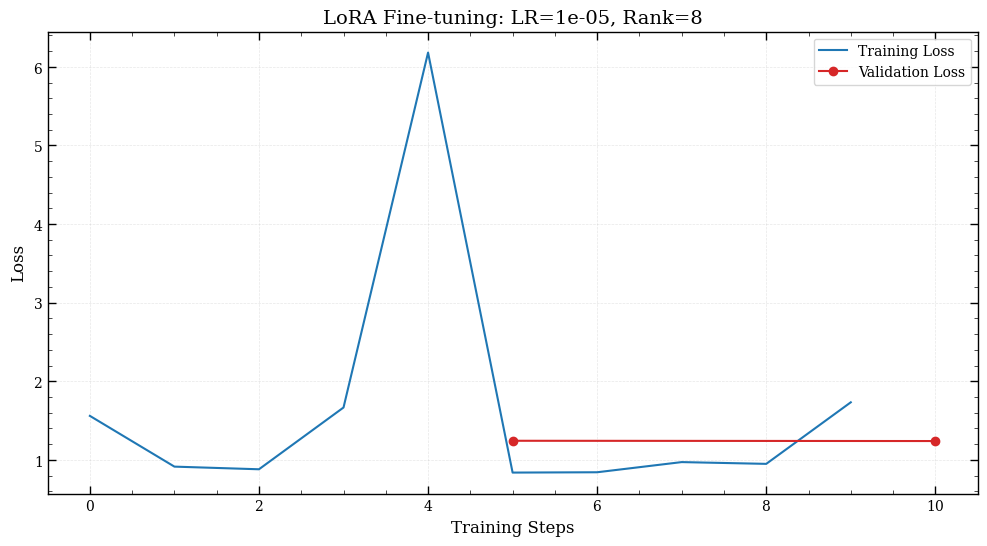

Experiment lr_1e-05_rank_8 completed. FLOPS used: 16,588,291,937,280
Total FLOPS used so far: 49,738,459,069,440 (0.05% of budget)


initial_perplexity,▁
initial_val_loss,▁
initial_perplexity,3.49036
initial_val_loss,1.25


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



--------------------------------------------------------------------------------
Running experiment: lr_5e-05_rank_2
--------------------------------------------------------------------------------


2025-03-23 14:48:31,619 - src.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-23 14:48:31,620 - src.lora - INFO - Applying LoRA with rank 2 and alpha 2
2025-03-23 14:48:31,621 - src.lora - INFO - Original trainable parameters: 151,936
2025-03-23 14:48:31,627 - src.lora - INFO - Applied LoRA with rank 2 to 48 ['q_proj', 'v_proj'] modules
2025-03-23 14:48:31,628 - src.lora - INFO - Trainable parameters: 287,104 (original: 151,936, ratio: 1.889638)
Evaluating: 100%|██████████| 20/20 [00:09<00:00,  2.18it/s]
2025-03-23 14:48:41,905 - src.lora - INFO - Training with batch_size=2, seq_length=256
2025-03-23 14:48:41,908 - src.lora - INFO - Output directory: ../results/lora/hyperparam_search/lr_5e-05_rank_2
2025-03-23 14:48:41,910 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:48:41,911 - src.lora - INFO - Estimated FLOPs per step: 1,656,715,854,336
2025-03-23 14:48:41,912 - src

Initial validation loss: 1.2500


Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.36it/s]
2025-03-23 14:48:56,867 - src.lora - INFO - Step 5: Eval loss = 1.2440, perplexity = 3.4694
Training: 100%|██████████| 10/10 [00:21<00:00,  1.98s/it, loss=1.79] 2025-03-23 14:49:03,742 - src.lora - INFO - Step 10: Train loss = 1.7880, FLOPS used = 1.66e+13
2025-03-23 14:49:03,742 - src.lora - INFO - Evaluating at step 10...
Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.32it/s]
2025-03-23 14:49:12,379 - src.lora - INFO - Step 10: Eval loss = 1.2399, perplexity = 3.4552
Training: 100%|██████████| 10/10 [00:30<00:00,  3.05s/it, loss=1.79]
2025-03-23 14:49:12,380 - src.lora - INFO - Training completed with 10 steps. Best eval loss: 1.2399
2025-03-23 14:49:12,384 - src.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 2, over 10 steps
2025-03-23 14:49:12,385 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:49:12,3

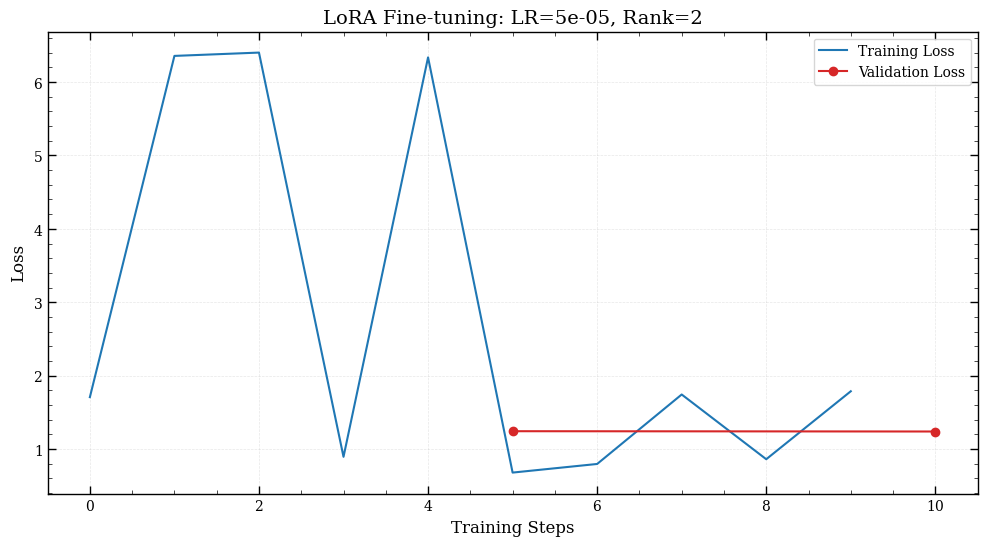

Experiment lr_5e-05_rank_2 completed. FLOPS used: 16,572,441,891,840
Total FLOPS used so far: 66,310,900,961,280 (0.07% of budget)


initial_perplexity,▁
initial_val_loss,▁
initial_perplexity,3.49036
initial_val_loss,1.25


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



--------------------------------------------------------------------------------
Running experiment: lr_5e-05_rank_4
--------------------------------------------------------------------------------


2025-03-23 14:49:20,523 - src.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-23 14:49:20,526 - src.lora - INFO - Applying LoRA with rank 4 and alpha 4
2025-03-23 14:49:20,527 - src.lora - INFO - Original trainable parameters: 151,936
2025-03-23 14:49:20,532 - src.lora - INFO - Applied LoRA with rank 4 to 48 ['q_proj', 'v_proj'] modules
2025-03-23 14:49:20,533 - src.lora - INFO - Trainable parameters: 422,272 (original: 151,936, ratio: 2.779275)
Evaluating: 100%|██████████| 20/20 [00:09<00:00,  2.22it/s]
2025-03-23 14:49:30,721 - src.lora - INFO - Training with batch_size=2, seq_length=256
2025-03-23 14:49:30,723 - src.lora - INFO - Output directory: ../results/lora/hyperparam_search/lr_5e-05_rank_4
2025-03-23 14:49:30,723 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:49:30,723 - src.lora - INFO - Estimated FLOPs per step: 1,656,715,854,336
2025-03-23 14:49:30,724 - src

Initial validation loss: 1.2500


Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.39it/s]
2025-03-23 14:49:45,638 - src.lora - INFO - Step 5: Eval loss = 1.2423, perplexity = 3.4635
Training: 100%|██████████| 10/10 [00:21<00:00,  1.93s/it, loss=5.48]2025-03-23 14:49:52,202 - src.lora - INFO - Step 10: Train loss = 5.4794, FLOPS used = 1.66e+13
2025-03-23 14:49:52,202 - src.lora - INFO - Evaluating at step 10...
Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.39it/s]
2025-03-23 14:50:00,579 - src.lora - INFO - Step 10: Eval loss = 1.2342, perplexity = 3.4358
Training: 100%|██████████| 10/10 [00:29<00:00,  2.99s/it, loss=5.48]
2025-03-23 14:50:00,581 - src.lora - INFO - Training completed with 10 steps. Best eval loss: 1.2342
2025-03-23 14:50:00,587 - src.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 4, over 10 steps
2025-03-23 14:50:00,588 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:50:00,58

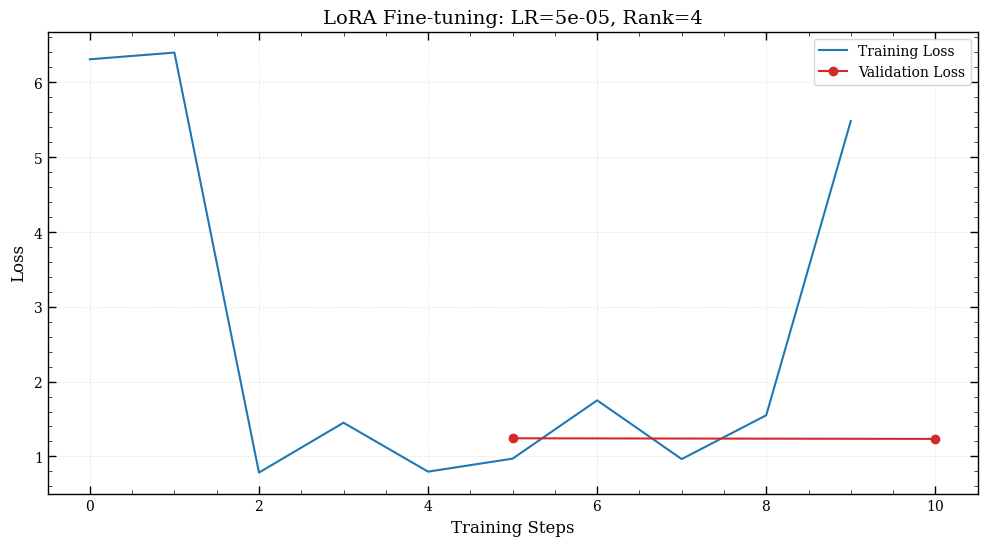

Experiment lr_5e-05_rank_4 completed. FLOPS used: 16,577,725,240,320
Total FLOPS used so far: 82,888,626,201,600 (0.08% of budget)


initial_perplexity,▁
initial_val_loss,▁
initial_perplexity,3.49036
initial_val_loss,1.25


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



--------------------------------------------------------------------------------
Running experiment: lr_5e-05_rank_8
--------------------------------------------------------------------------------


2025-03-23 14:50:06,318 - src.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-23 14:50:06,319 - src.lora - INFO - Applying LoRA with rank 8 and alpha 8
2025-03-23 14:50:06,319 - src.lora - INFO - Original trainable parameters: 151,936
2025-03-23 14:50:06,326 - src.lora - INFO - Applied LoRA with rank 8 to 48 ['q_proj', 'v_proj'] modules
2025-03-23 14:50:06,327 - src.lora - INFO - Trainable parameters: 692,608 (original: 151,936, ratio: 4.558551)
Evaluating: 100%|██████████| 20/20 [00:09<00:00,  2.20it/s]
2025-03-23 14:50:16,534 - src.lora - INFO - Training with batch_size=2, seq_length=256
2025-03-23 14:50:16,535 - src.lora - INFO - Output directory: ../results/lora/hyperparam_search/lr_5e-05_rank_8
2025-03-23 14:50:16,535 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:50:16,536 - src.lora - INFO - Estimated FLOPs per step: 1,656,715,854,336
2025-03-23 14:50:16,536 - src

Initial validation loss: 1.2500


Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.34it/s]
2025-03-23 14:50:31,733 - src.lora - INFO - Step 5: Eval loss = 1.2374, perplexity = 3.4466
Training: 100%|██████████| 10/10 [00:21<00:00,  1.96s/it, loss=1.71] 2025-03-23 14:50:38,473 - src.lora - INFO - Step 10: Train loss = 1.7066, FLOPS used = 1.66e+13
2025-03-23 14:50:38,474 - src.lora - INFO - Evaluating at step 10...
Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.42it/s]
2025-03-23 14:50:46,755 - src.lora - INFO - Step 10: Eval loss = 1.2234, perplexity = 3.3988
Training: 100%|██████████| 10/10 [00:30<00:00,  3.02s/it, loss=1.71]
2025-03-23 14:50:46,756 - src.lora - INFO - Training completed with 10 steps. Best eval loss: 1.2234
2025-03-23 14:50:46,758 - src.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 8, over 10 steps
2025-03-23 14:50:46,758 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:50:46,7

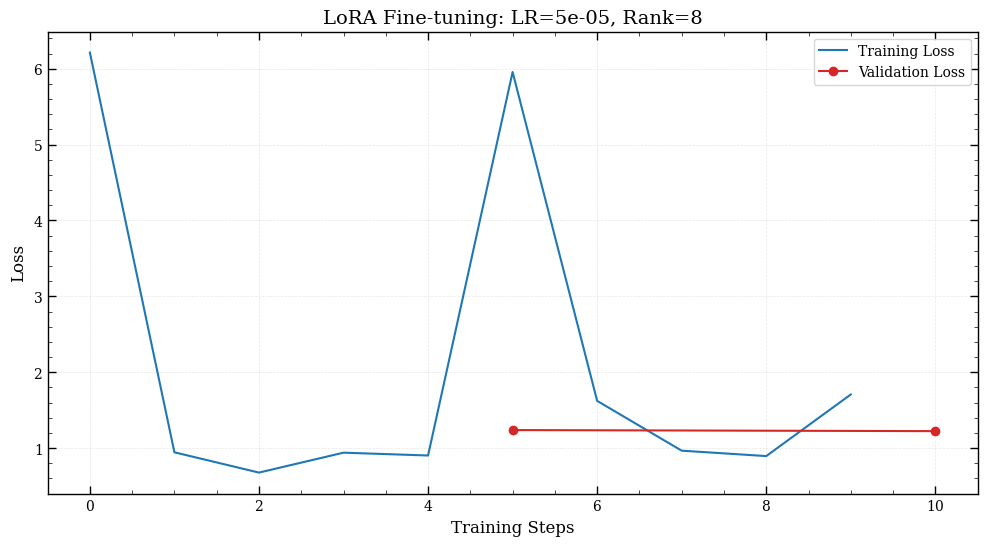

Experiment lr_5e-05_rank_8 completed. FLOPS used: 16,588,291,937,280
Total FLOPS used so far: 99,476,918,138,880 (0.10% of budget)


initial_perplexity,▁
initial_val_loss,▁
initial_perplexity,3.49036
initial_val_loss,1.25


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



--------------------------------------------------------------------------------
Running experiment: lr_1e-04_rank_2
--------------------------------------------------------------------------------


2025-03-23 14:50:52,724 - src.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-23 14:50:52,726 - src.lora - INFO - Applying LoRA with rank 2 and alpha 2
2025-03-23 14:50:52,727 - src.lora - INFO - Original trainable parameters: 151,936
2025-03-23 14:50:52,733 - src.lora - INFO - Applied LoRA with rank 2 to 48 ['q_proj', 'v_proj'] modules
2025-03-23 14:50:52,734 - src.lora - INFO - Trainable parameters: 287,104 (original: 151,936, ratio: 1.889638)
Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.25it/s]
2025-03-23 14:51:02,666 - src.lora - INFO - Training with batch_size=2, seq_length=256
2025-03-23 14:51:02,668 - src.lora - INFO - Output directory: ../results/lora/hyperparam_search/lr_1e-04_rank_2
2025-03-23 14:51:02,669 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:51:02,669 - src.lora - INFO - Estimated FLOPs per step: 1,656,715,854,336
2025-03-23 14:51:02,670 - src

Initial validation loss: 1.2500


Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.38it/s]
2025-03-23 14:51:17,607 - src.lora - INFO - Step 5: Eval loss = 1.2418, perplexity = 3.4618
Training: 100%|██████████| 10/10 [00:21<00:00,  1.96s/it, loss=5.88] 2025-03-23 14:51:24,238 - src.lora - INFO - Step 10: Train loss = 5.8781, FLOPS used = 1.66e+13
2025-03-23 14:51:24,239 - src.lora - INFO - Evaluating at step 10...
Evaluating: 100%|██████████| 20/20 [00:09<00:00,  2.20it/s]
2025-03-23 14:51:33,374 - src.lora - INFO - Step 10: Eval loss = 1.2325, perplexity = 3.4298
Training: 100%|██████████| 10/10 [00:30<00:00,  3.07s/it, loss=5.88]
2025-03-23 14:51:33,440 - src.lora - INFO - Training completed with 10 steps. Best eval loss: 1.2325
2025-03-23 14:51:36,129 - src.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 2, over 10 steps
2025-03-23 14:51:36,202 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:51:36,2

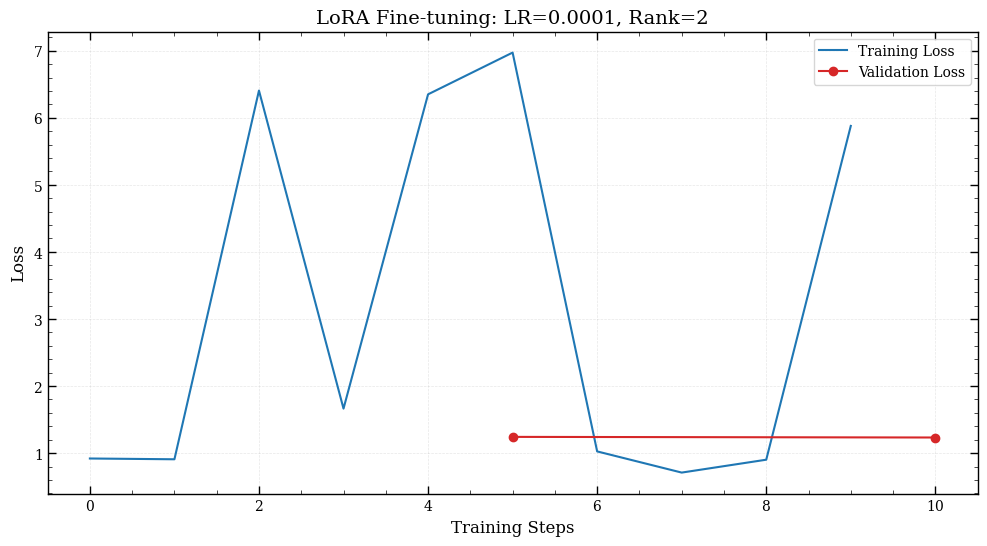

Experiment lr_1e-04_rank_2 completed. FLOPS used: 16,572,441,891,840
Total FLOPS used so far: 116,049,360,030,720 (0.12% of budget)


initial_perplexity,▁
initial_val_loss,▁
initial_perplexity,3.49036
initial_val_loss,1.25


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



--------------------------------------------------------------------------------
Running experiment: lr_1e-04_rank_4
--------------------------------------------------------------------------------


2025-03-23 14:51:50,367 - src.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-23 14:51:50,390 - src.lora - INFO - Applying LoRA with rank 4 and alpha 4
2025-03-23 14:51:50,396 - src.lora - INFO - Original trainable parameters: 151,936
2025-03-23 14:51:50,429 - src.lora - INFO - Applied LoRA with rank 4 to 48 ['q_proj', 'v_proj'] modules
2025-03-23 14:51:50,429 - src.lora - INFO - Trainable parameters: 422,272 (original: 151,936, ratio: 2.779275)
Evaluating: 100%|██████████| 20/20 [04:25<00:00, 13.27s/it]
2025-03-23 14:56:42,409 - src.lora - INFO - Training with batch_size=2, seq_length=256
2025-03-23 14:56:42,420 - src.lora - INFO - Output directory: ../results/lora/hyperparam_search/lr_1e-04_rank_4
2025-03-23 14:56:42,428 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:56:42,429 - src.lora - INFO - Estimated FLOPs per step: 1,656,715,854,336
2025-03-23 14:56:42,430 - src

Initial validation loss: 1.2500


Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.27it/s]
2025-03-23 14:57:05,276 - src.lora - INFO - Step 5: Eval loss = 1.2062, perplexity = 3.3407
Training: 100%|██████████| 10/10 [00:29<00:00,  2.14s/it, loss=1.61]2025-03-23 14:57:12,376 - src.lora - INFO - Step 10: Train loss = 1.6072, FLOPS used = 1.66e+13
2025-03-23 14:57:12,378 - src.lora - INFO - Evaluating at step 10...
Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.39it/s]
2025-03-23 14:57:20,848 - src.lora - INFO - Step 10: Eval loss = 1.1766, perplexity = 3.2432
Training: 100%|██████████| 10/10 [00:38<00:00,  3.84s/it, loss=1.61]
2025-03-23 14:57:20,851 - src.lora - INFO - Training completed with 10 steps. Best eval loss: 1.1766
2025-03-23 14:57:20,924 - src.flops_calculator - INFO - Calculating LoRA FLOPs for 48 modules with rank 4, over 10 steps
2025-03-23 14:57:20,943 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 14:57:20,94

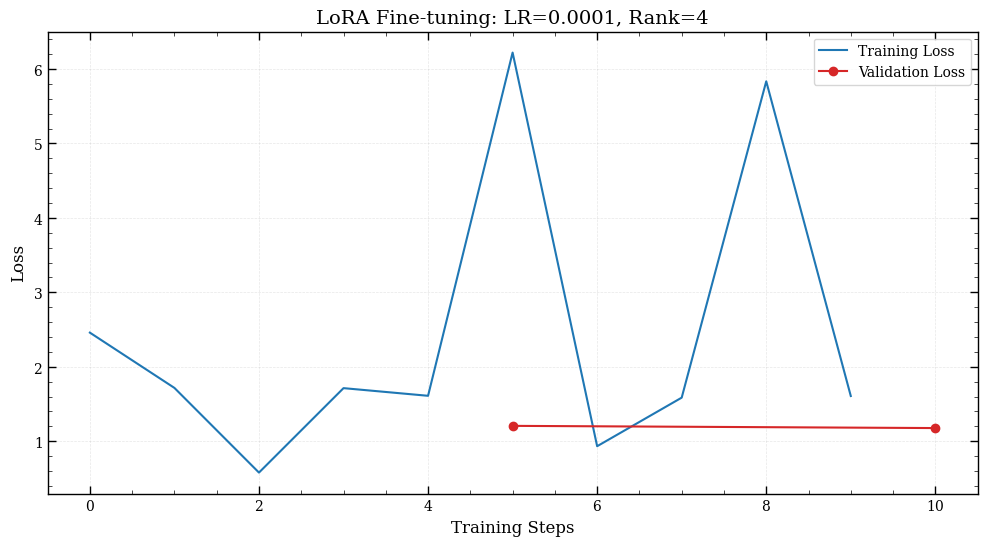

Experiment lr_1e-04_rank_4 completed. FLOPS used: 16,577,725,240,320
Total FLOPS used so far: 132,627,085,271,040 (0.13% of budget)


initial_perplexity,▁
initial_val_loss,▁
initial_perplexity,3.49036
initial_val_loss,1.25


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



--------------------------------------------------------------------------------
Running experiment: lr_1e-04_rank_8
--------------------------------------------------------------------------------


2025-03-23 14:57:41,063 - src.lora - INFO - Using default target modules: ['q_proj', 'v_proj']
2025-03-23 14:57:41,066 - src.lora - INFO - Applying LoRA with rank 8 and alpha 8
2025-03-23 14:57:41,067 - src.lora - INFO - Original trainable parameters: 151,936
2025-03-23 14:57:41,085 - src.lora - INFO - Applied LoRA with rank 8 to 48 ['q_proj', 'v_proj'] modules
2025-03-23 14:57:41,086 - src.lora - INFO - Trainable parameters: 692,608 (original: 151,936, ratio: 4.558551)
Evaluating: 100%|██████████| 20/20 [01:46<00:00,  5.32s/it]


Initial validation loss: 1.2500


2025-03-23 15:00:07,146 - src.lora - INFO - Training with batch_size=2, seq_length=256
2025-03-23 15:00:07,182 - src.lora - INFO - Output directory: ../results/lora/hyperparam_search/lr_1e-04_rank_8
2025-03-23 15:00:07,203 - src.flops_calculator - INFO - Training FLOPs: forward=552,238,618,112, backward=1,104,477,236,224, total=1,656,715,854,336
2025-03-23 15:00:07,203 - src.lora - INFO - Estimated FLOPs per step: 1,656,715,854,336
2025-03-23 15:00:07,204 - src.lora - INFO - Starting training for 10 steps
Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.26it/s]
2025-03-23 15:00:38,383 - src.lora - INFO - Step 5: Eval loss = 1.2070, perplexity = 3.3435
Training: 100%|██████████| 10/10 [00:37<00:00,  2.23s/it, loss=0.95]2025-03-23 15:00:45,104 - src.lora - INFO - Step 10: Train loss = 0.9499, FLOPS used = 1.66e+13
2025-03-23 15:00:45,105 - src.lora - INFO - Evaluating at step 10...
Evaluating: 100%|██████████| 20/20 [00:08<00:00,  2.24it/s]
2025-03-23 15:00:54,070 - src.lora - INFO - 

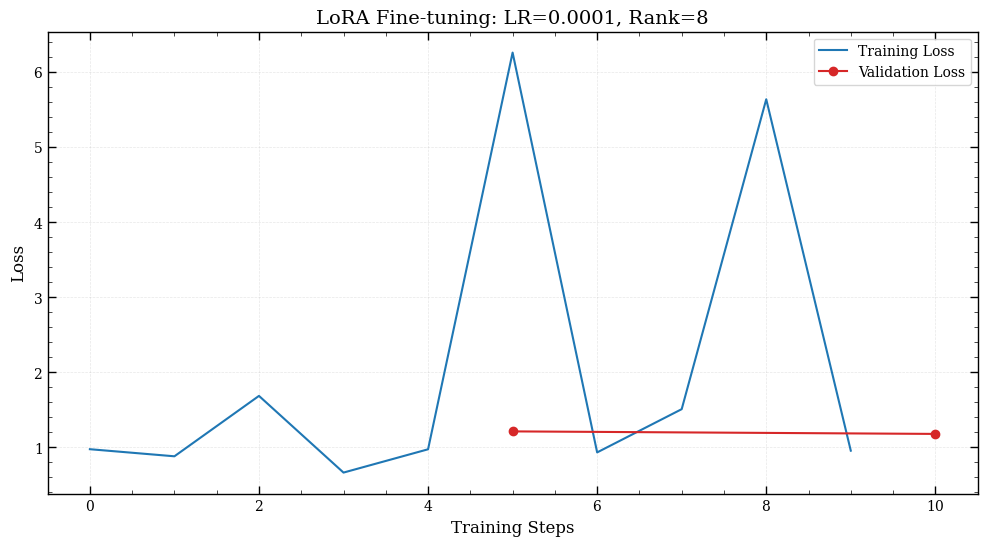

Experiment lr_1e-04_rank_8 completed. FLOPS used: 16,588,291,937,280
Total FLOPS used so far: 149,215,377,208,320 (0.15% of budget)


initial_perplexity,▁
initial_val_loss,▁
initial_perplexity,3.49036
initial_val_loss,1.25


In [42]:
# Hyperparameter search loop
for lr, r in itertools.product(learning_rates, lora_ranks):
    # Create experiment name and output directory
    exp_name = f"lr_{lr:.0e}_rank_{r}"
    exp_output_dir = os.path.join(base_output_dir, exp_name)
    os.makedirs(exp_output_dir, exist_ok=True)
    
    # Initialize a new W&B run for this experiment
    run = wandb.init(project="lora-hyperparameter-search", name=exp_name, reinit=True)
    
    # Log hyperparameters for this experiment
    wandb.config.update({
        "learning_rate": lr,
        "lora_rank": r,
        "context_length": max_ctx_length
    })
    
    print(f"\n{'-'*80}\nRunning experiment: {exp_name}\n{'-'*80}")
    
    # Re-initialize model and apply LoRA
    model, tokenizer = load_qwen()
    model = apply_lora_to_model(model, r=r)
    
    # Setup optimizer with current learning rate
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr
    )
    
    # Setup accelerator for efficient training
    accelerator = Accelerator()
    model, optimizer, train_loader_acc, val_loader_acc = accelerator.prepare(
        model, optimizer, train_loader, val_loader
    )
    
    # Initial evaluation
    initial_metrics = evaluate_model(model, val_loader_acc, accelerator)
    print(f"Initial validation loss: {initial_metrics['loss']:.4f}")
    # Log initial metrics
    wandb.log({"initial_val_loss": initial_metrics['loss'], 
               "initial_perplexity": initial_metrics['perplexity']})
    
    # Train the model
    train_stats = train_lora(
        model=model,
        train_loader=train_loader_acc,
        optimizer=optimizer,
        accelerator=accelerator,
        max_steps=max_steps,
        eval_loader=val_loader_acc,
        eval_steps=eval_steps,
        logging_steps=logging_steps,
        output_dir=exp_output_dir,
        model_name=exp_name,
        save_best=False,
        save_final=False
    )
    
    # Save training stats so they can be loaded later for visualization
    with open(os.path.join(exp_output_dir, 'training_stats.json'), 'w') as f:
        json.dump(train_stats, f, indent=2)
    
    # Calculate FLOPS used
    flops_used = calculate_lora_flops(
        batch_size=batch_size,
        seq_length=max_ctx_length,
        r=r,
        steps=train_stats['steps']
    )['combined_total']
    
    total_flops_used += flops_used
    
    # Record results
    result = {
        'learning_rate': lr,
        'lora_rank': r,
        'context_length': max_ctx_length,
        'steps': train_stats['steps'],
        'final_train_loss': train_stats['train_losses'][-1],
        'best_val_loss': min(train_stats['eval_losses']),
        'best_val_step': train_stats['eval_steps'][np.argmin(train_stats['eval_losses'])],
        'final_val_loss': train_stats['eval_losses'][-1],
        'flops_used': flops_used
    }
    results.append(result)
    
    # Save results so far
    with open(os.path.join(base_output_dir, 'results.json'), 'w') as f:
        json.dump({
            'results': results,
            'total_flops_used': total_flops_used
        }, f, indent=2)
    
    # Visualize training progress
    plt.figure(figsize=(12, 6))
    plt.plot(train_stats['train_losses'], label='Training Loss')
    plt.plot(train_stats['eval_steps'], train_stats['eval_losses'], 'o-', label='Validation Loss')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title(f'LoRA Fine-tuning: LR={lr}, Rank={r}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(exp_output_dir, 'training_curve.pdf'))
    plt.show()
    
    # Clear memory
    del model, optimizer, accelerator
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    print(f"Experiment {exp_name} completed. FLOPS used: {flops_used:,.0f}")
    print(f"Total FLOPS used so far: {total_flops_used:,.0f} ({total_flops_used/1e17:.2%} of budget)")

    run.finish()

## 5. Results Analysis


In [43]:
# Load and process results
with open(os.path.join(base_output_dir, 'results.json'), 'r') as f:
    search_results = json.load(f)

results_df = pd.DataFrame(search_results['results'])

# Display all results sorted by validation loss
display(results_df.sort_values('best_val_loss'))

# Identify best hyperparameters
best_idx = results_df['best_val_loss'].argmin()
best_config = results_df.iloc[best_idx]
print(f"\nBest configuration:")
print(f"Learning rate: {best_config['learning_rate']}")
print(f"LoRA rank: {best_config['lora_rank']}")
print(f"Best validation loss: {best_config['best_val_loss']:.4f} at step {best_config['best_val_step']}")
print(f"FLOPS used: {best_config['flops_used']:,.0f}")

,learning_rate,lora_rank,context_length,steps,final_train_loss,best_val_loss,best_val_step,final_val_loss,flops_used
8,0.00010,8,256,10,0.949933,1.173327,10,1.173327,16588291937280
7,0.00010,4,256,10,1.607175,1.176572,10,1.176572,16577725240320
5,0.00005,8,256,10,1.706565,1.223415,10,1.223415,16588291937280
6,0.00010,2,256,10,5.878110,1.232512,10,1.232512,16572441891840
4,0.00005,4,256,10,5.479407,1.234243,10,1.234243,16577725240320
3,0.00005,2,256,10,1.788023,1.239866,10,1.239866,16572441891840
2,0.00001,8,256,10,1.732719,1.239923,10,1.239923,16588291937280
1,0.00001,4,256,10,1.017098,1.245846,10,1.245846,16577725240320
0,0.00001,2,256,10,1.623058,1.248810,10,1.248810,16572441891840



Best configuration:
Learning rate: 0.0001
LoRA rank: 8.0
Best validation loss: 1.1733 at step 10.0
FLOPS used: 16,588,291,937,280


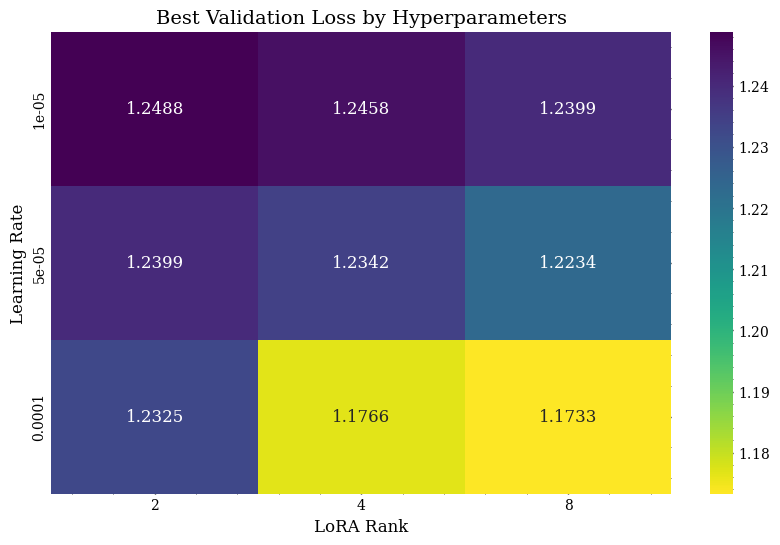

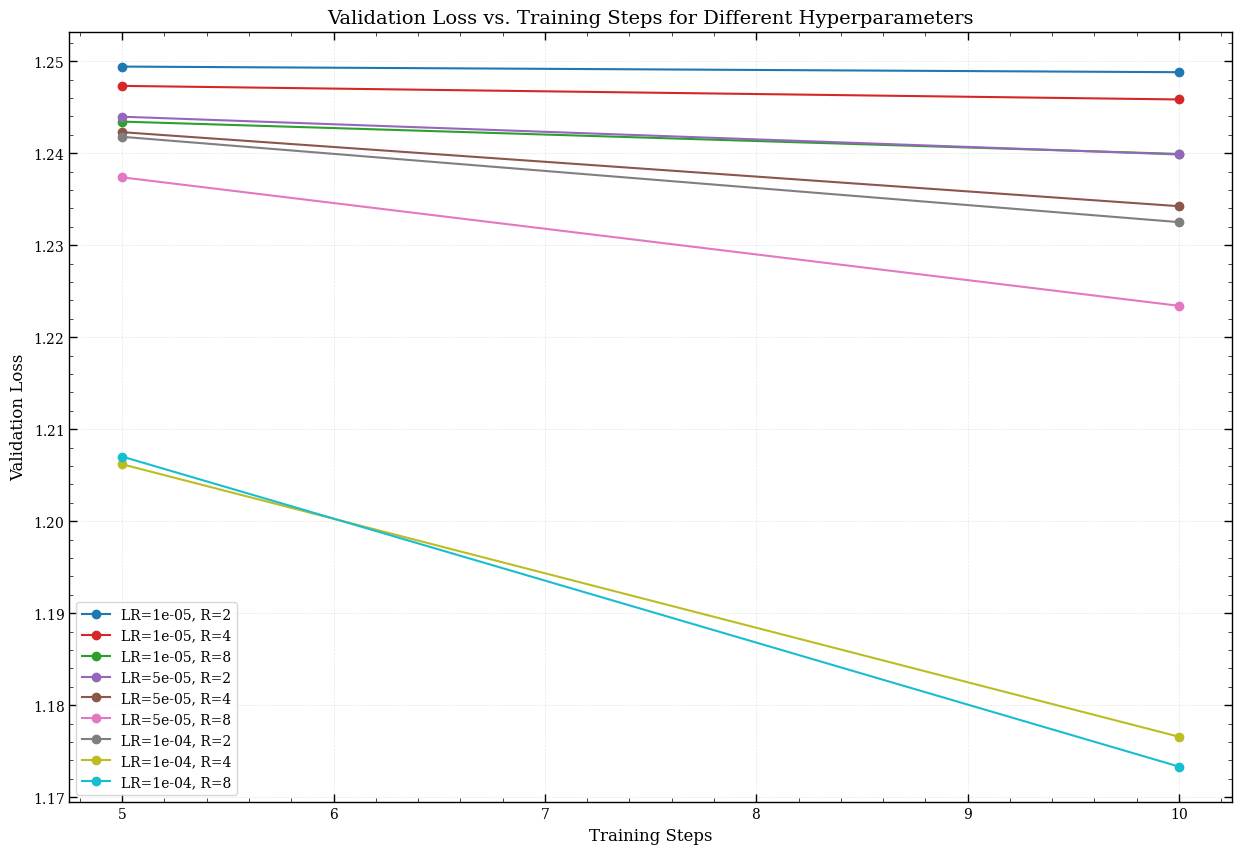

In [44]:
# Visualize results with heatmap
pivot_results = results_df.pivot(index='learning_rate', columns='lora_rank', values='best_val_loss')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_results, annot=True, fmt='.4f', cmap='viridis_r')
plt.title('Best Validation Loss by Hyperparameters')
plt.xlabel('LoRA Rank')
plt.ylabel('Learning Rate')
plt.savefig(os.path.join(base_output_dir, 'heatmap_results.pdf'))
plt.show()

# Visualize learning curves for all experiments
plt.figure(figsize=(15, 10))
for i, result in enumerate(search_results['results']):
    exp_name = f"lr_{result['learning_rate']:.0e}_rank_{result['lora_rank']}"
    exp_dir = os.path.join(base_output_dir, exp_name)
    
    # Load training stats
    with open(os.path.join(exp_dir, 'training_stats.json'), 'r') as f:
        stats = json.load(f)
    
    plt.plot(stats['eval_steps'], stats['eval_losses'], 'o-', 
             label=f"LR={result['learning_rate']:.0e}, R={result['lora_rank']}")

plt.xlabel('Training Steps')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs. Training Steps for Different Hyperparameters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(base_output_dir, 'all_learning_curves.pdf'))
plt.show()